# Регрессия на реальном датасете

import numpy as np
import matplotlib.pyplot as plt 
import pandas as pd

In [78]:
import numpy as np
import matplotlib.pyplot as plt 
import pandas as pd

In [79]:
from sklearn.datasets import fetch_california_housing
california = fetch_california_housing()

type(california)


sklearn.utils._bunch.Bunch

In [80]:
california.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'feature_names', 'DESCR'])

In [81]:
print(type(california.data), type(california.target))

<class 'numpy.ndarray'> <class 'numpy.ndarray'>


In [82]:
print(california.data.shape, california.target.shape)

(20640, 8) (20640,)


In [83]:
data = pd.DataFrame(california.data, columns = california.feature_names)
data['Price'] = california.target
data.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [84]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
 8   Price       20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [85]:
data.describe().round(2)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
count,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00
mean,3.87,28.64,5.43,1.10,1425.48,3.07,35.63,-119.57,2.07
std,1.90,12.59,2.47,0.47,1132.46,10.39,2.14,2.00,1.15
min,0.50,1.00,0.85,0.33,3.00,0.69,32.54,-124.35,0.15
25%,2.56,18.00,4.44,1.01,787.00,2.43,33.93,-121.80,1.20
50%,3.53,29.00,5.23,1.05,1166.00,2.82,34.26,-118.49,1.80
75%,4.74,37.00,6.05,1.10,1725.00,3.28,37.71,-118.01,2.65
max,15.00,52.00,141.91,34.07,35682.00,1243.33,41.95,-114.31,5.00


In [86]:
y = data['Price']
X = data.drop('Price', axis=1)

In [87]:
y.shape, X.shape

((20640,), (20640, 8))

In [88]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [89]:
print("Coefficients: \n", model.coef_)

Coefficients: 
 [ 4.36693293e-01  9.43577803e-03 -1.07322041e-01  6.45065694e-01
 -3.97638942e-06 -3.78654265e-03 -4.21314378e-01 -4.34513755e-01]


In [90]:
_ = [print(k, v) for k, v in zip(X.columns, model.coef_)]

MedInc 0.4366932931343249
HouseAge 0.009435778033238185
AveRooms -0.10732204139090434
AveBedrms 0.6450656935198135
Population -3.976389421210415e-06
AveOccup -0.0037865426549710075
Latitude -0.42131437752714485
Longitude -0.4345137546747772


In [91]:
print("Intercept: \n", model.intercept_)

Intercept: 
 -36.94192020718437


In [92]:
y_pred = model.predict(X)
print(y_pred[:5])

[4.13164983 3.97660644 3.67657094 3.2415985  2.41358744]


In [93]:
print(y[:5])

0    4.526
1    3.585
2    3.521
3    3.413
4    3.422
Name: Price, dtype: float64


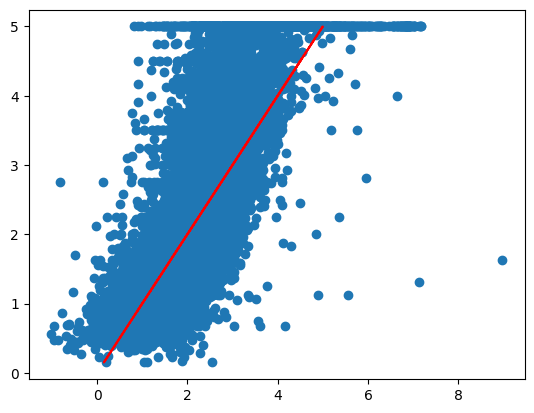

In [94]:
plt.scatter(y_pred, y)
plt.plot(y, y, c='r')

In [95]:
model.score(X, y)

0.606232685199805

0.6832976293317483


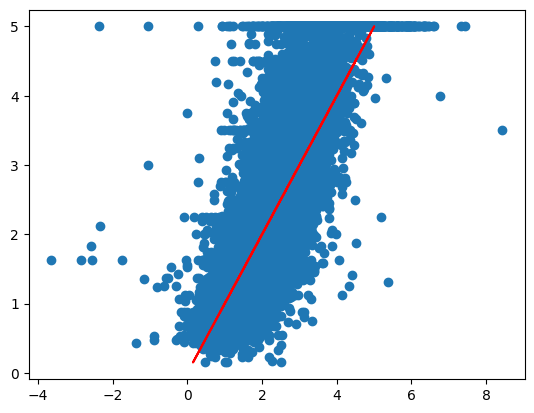

In [96]:
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression


scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X)   # без StandardScaler
model = LinearRegression()
model.fit(X_poly, y)

print(model.score(X_poly, y))

y_pred = model_poly.predict(X_poly)
plt.scatter(y_pred, y); plt.plot(y, y, 'r')




In [97]:
print(model_poly.score(X_poly, y))

0.6832976293317483


# Для самостоятельного решения

## Задание 1: Дополнительная информация о модели, влияние аргументов

In [99]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

base = LinearRegression().fit(X, y)
y_pred = base.predict(X)

print("R²:         ", round(base.score(X, y), 4))
print("MAE:        ", round(mean_absolute_error(y, y_pred), 4))
print("RMSE:       ", round(mean_squared_error(y, y_pred) ** 0.5, 4))
print("intercept:  ", round(base.intercept_, 4))
print("n_features: ", base.n_features_in_)

# fit_intercept=False — без свободного члена
no_intercept = LinearRegression(fit_intercept=False).fit(X, y)
print("\nfit_intercept=False -> R²:", round(no_intercept.score(X, y), 4))

# positive=True — только неотрицательные коэффициенты
pos = LinearRegression(positive=True).fit(X, y)
print("positive=True       -> R²:", round(pos.score(X, y), 4))

R²:          0.6062
MAE:         0.5312
RMSE:        0.7241
intercept:   -36.9419
n_features:  8

fit_intercept=False -> R²: 0.5462
positive=True       -> R²: 0.5102


## Задание 2–3: Все модели регрессии + функция авто-обучения

In [100]:
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, BaggingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

# Словарь всех моделей (задание 2)
MODELS = {
    "LinearRegression":   LinearRegression(),
    "SVR (linear)":       make_pipeline(StandardScaler(), SVR(kernel='linear')),
    "SVR (rbf)":          make_pipeline(StandardScaler(), SVR(kernel='rbf')),
    "SVR (poly)":         make_pipeline(StandardScaler(), SVR(kernel='poly', degree=3)),
    "KNeighbors":         KNeighborsRegressor(),
    "MLP":                make_pipeline(StandardScaler(), MLPRegressor(max_iter=500, random_state=0)),
    "DecisionTree":       DecisionTreeRegressor(random_state=0),
    "Ridge":              Ridge(),
    "Lasso":              Lasso(),
    "ElasticNet":         ElasticNet(),
    "RandomForest":       RandomForestRegressor(n_estimators=50, random_state=0),
    "Bagging":            BaggingRegressor(n_estimators=20, random_state=0),
}


def evaluate_models(X, y, models=MODELS):
    """Задание 3: обучает все модели, возвращает DataFrame с метриками."""
    rows = []
    for name, m in models.items():
        m.fit(X, y)
        yp = m.predict(X)
        rows.append({
            "модель": name,
            "R²":   m.score(X, y),
            "MAE":  mean_absolute_error(y, yp),
            "RMSE": mean_squared_error(y, yp) ** 0.5,
        })
    return pd.DataFrame(rows).set_index("модель").round(4)


results_ca = evaluate_models(X, y)
results_ca.sort_values("R²", ascending=False)

,R²,MAE,RMSE
модель,,,
DecisionTree,1.0000,0.0000,0.0000
RandomForest,0.9727,0.1219,0.1908
Bagging,0.9690,0.1281,0.2032
MLP,0.7986,0.3600,0.5179
SVR (rbf),0.7502,0.3816,0.5767
LinearRegression,0.6062,0.5312,0.7241
Ridge,0.6062,0.5312,0.7241
SVR (poly),0.4728,0.5720,0.8378
KNeighbors,0.4711,0.6423,0.8392


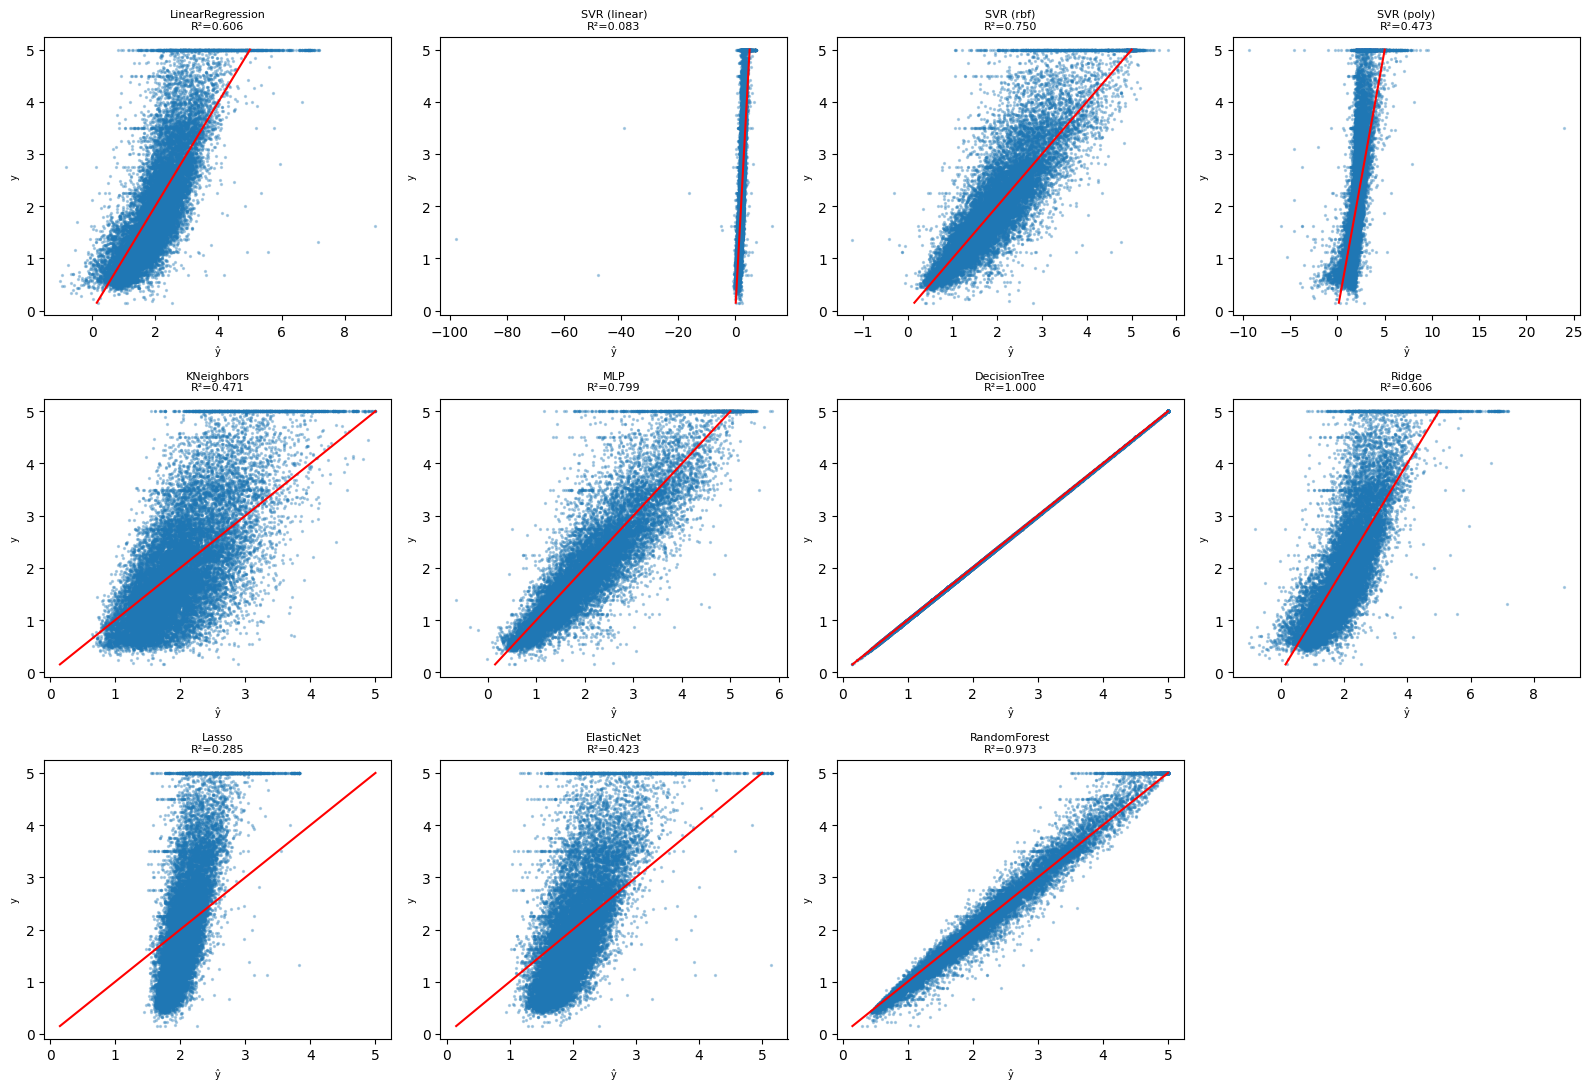

In [101]:
# Визуализация: предсказание vs факт для каждой модели
fig, axes = plt.subplots(3, 4, figsize=(16, 11))
axes = axes.ravel()

for ax, (name, m) in zip(axes, MODELS.items()):
    yp = m.predict(X)
    ax.scatter(yp, y, s=2, alpha=0.3)
    ax.plot([y.min(), y.max()], [y.min(), y.max()], 'r')
    ax.set_title(f"{name}\nR²={m.score(X,y):.3f}", fontsize=8)
    ax.set_xlabel("ŷ", fontsize=7)
    ax.set_ylabel("y", fontsize=7)

# убираем лишнюю ячейку
fig.delaxes(axes[-1])
plt.tight_layout()
plt.show()

## Задание 4: Повтор анализа на датасете Diabetes

In [102]:
from sklearn.datasets import load_diabetes

diab = load_diabetes()
X_d = pd.DataFrame(diab.data, columns=diab.feature_names)
y_d = pd.Series(diab.target, name='target')

print(X_d.shape)
X_d.describe().round(2)

(442, 10)


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
count,442.00,442.00,442.00,442.00,442.00,442.00,442.00,442.00,442.00,442.00
mean,-0.00,0.00,-0.00,-0.00,-0.00,0.00,-0.00,-0.00,0.00,0.00
std,0.05,0.05,0.05,0.05,0.05,0.05,0.05,0.05,0.05,0.05
min,-0.11,-0.04,-0.09,-0.11,-0.13,-0.12,-0.10,-0.08,-0.13,-0.14
25%,-0.04,-0.04,-0.03,-0.04,-0.03,-0.03,-0.04,-0.04,-0.03,-0.03
50%,0.01,-0.04,-0.01,-0.01,-0.00,-0.00,-0.01,-0.00,-0.00,-0.00
75%,0.04,0.05,0.03,0.04,0.03,0.03,0.03,0.03,0.03,0.03
max,0.11,0.05,0.17,0.13,0.15,0.20,0.18,0.19,0.13,0.14


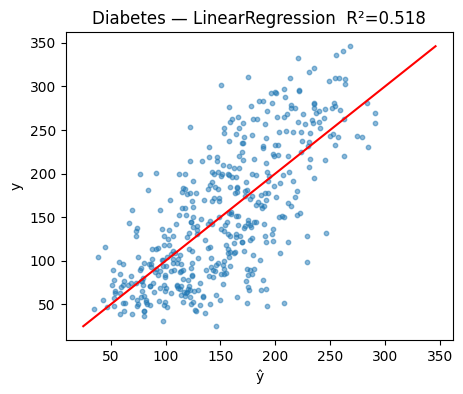

In [103]:
# Множественная линейная регрессия
base_d = LinearRegression().fit(X_d, y_d)
y_pred_d = base_d.predict(X_d)

plt.figure(figsize=(5, 4))
plt.scatter(y_pred_d, y_d, s=10, alpha=0.5)
plt.plot([y_d.min(), y_d.max()], [y_d.min(), y_d.max()], 'r')
plt.title(f"Diabetes — LinearRegression  R²={base_d.score(X_d, y_d):.3f}")
plt.xlabel("ŷ"); plt.ylabel("y")
plt.show()

In [104]:
# Все модели на Diabetes через ту же функцию
# Пересоздаём экземпляры (предыдущие уже обучены на California)
MODELS_D = {
    "LinearRegression":   LinearRegression(),
    "SVR (linear)":       make_pipeline(StandardScaler(), SVR(kernel='linear')),
    "SVR (rbf)":          make_pipeline(StandardScaler(), SVR(kernel='rbf')),
    "SVR (poly)":         make_pipeline(StandardScaler(), SVR(kernel='poly', degree=3)),
    "KNeighbors":         KNeighborsRegressor(),
    "MLP":                make_pipeline(StandardScaler(), MLPRegressor(max_iter=500, random_state=0)),
    "DecisionTree":       DecisionTreeRegressor(random_state=0),
    "Ridge":              Ridge(),
    "Lasso":              Lasso(),
    "ElasticNet":         ElasticNet(),
    "RandomForest":       RandomForestRegressor(n_estimators=50, random_state=0),
    "Bagging":            BaggingRegressor(n_estimators=20, random_state=0),
}

results_d = evaluate_models(X_d, y_d, models=MODELS_D)
results_d.sort_values("R²", ascending=False)

/Users/cancer/Технология решений задач ML/myenv/lib/python3.14/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


,R²,MAE,RMSE
модель,,,
DecisionTree,1.0000,0.0000,0.0000
RandomForest,0.9106,17.8635,23.0187
Bagging,0.9022,18.7544,24.0833
KNeighbors,0.6050,37.5869,48.4000
LinearRegression,0.5177,43.2775,53.4761
SVR (linear),0.5088,43.4426,53.9711
MLP,0.4588,44.8345,56.6507
Ridge,0.4512,47.6074,57.0451
Lasso,0.3574,52.5449,61.7306


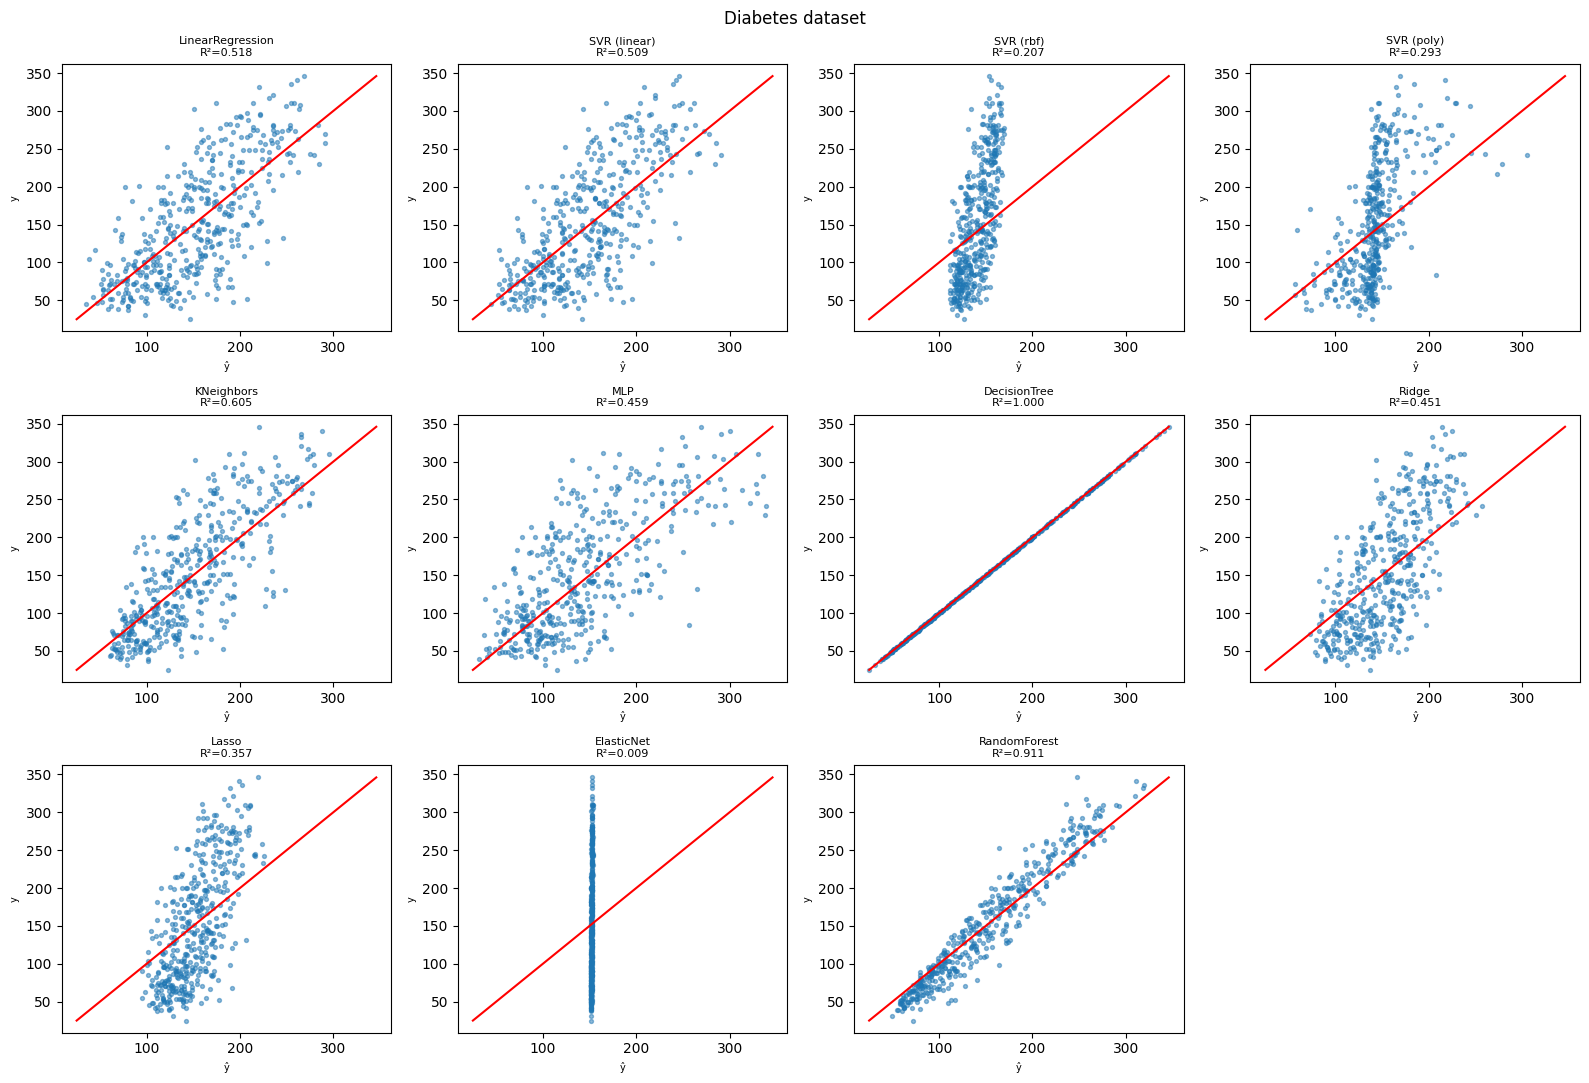

In [105]:
# Визуализация для Diabetes
fig, axes = plt.subplots(3, 4, figsize=(16, 11))
axes = axes.ravel()

for ax, (name, m) in zip(axes, MODELS_D.items()):
    yp = m.predict(X_d)
    ax.scatter(yp, y_d, s=8, alpha=0.5)
    ax.plot([y_d.min(), y_d.max()], [y_d.min(), y_d.max()], 'r')
    ax.set_title(f"{name}\nR²={m.score(X_d, y_d):.3f}", fontsize=8)
    ax.set_xlabel("ŷ", fontsize=7); ax.set_ylabel("y", fontsize=7)

fig.delaxes(axes[-1])
plt.suptitle("Diabetes dataset", fontsize=12)
plt.tight_layout()
plt.show()

In [106]:
# Сравнение датасетов рядом
print("=== California ===")
print(results_ca.sort_values("R²", ascending=False).to_string())
print("\n=== Diabetes ===")
print(results_d.sort_values("R²", ascending=False).to_string())

=== California ===
                      R²     MAE    RMSE
модель                                  
DecisionTree      1.0000  0.0000  0.0000
RandomForest      0.9727  0.1219  0.1908
Bagging           0.9690  0.1281  0.2032
MLP               0.7986  0.3600  0.5179
SVR (rbf)         0.7502  0.3816  0.5767
LinearRegression  0.6062  0.5312  0.7241
Ridge             0.6062  0.5312  0.7241
SVR (poly)        0.4728  0.5720  0.8378
KNeighbors        0.4711  0.6423  0.8392
ElasticNet        0.4231  0.6793  0.8765
Lasso             0.2853  0.7679  0.9756
SVR (linear)      0.0826  0.5108  1.1053

=== Diabetes ===
                      R²      MAE     RMSE
модель                                    
DecisionTree      1.0000   0.0000   0.0000
RandomForest      0.9106  17.8635  23.0187
Bagging           0.9022  18.7544  24.0833
KNeighbors        0.6050  37.5869  48.4000
LinearRegression  0.5177  43.2775  53.4761
SVR (linear)      0.5088  43.4426  53.9711
MLP               0.4588  44.8345  56.6507
Ri